# Project 1: Data Analysis Project

## Table of contents <a id='toc0_'></a>
- [Question 1: Inequality in Denmark](#toc1_)
  - [Question 1.1: The Gini Coefficient and the Top 10 Percent Share](#toc1_1_)
  - [Question 1.2: Prediction](#toc1_2_)
  - [Question 1.3: Municipalities](#toc1_3_)
  - [Question 1.4: Extension](#toc1_4_)
- [Question 2: Simulating the Income Distribution](#toc2_)
  - [Question 2.1: The Model](#toc2_1_)
  - [Question 2.2: Simulate the Income Distribution](#toc2_2_)
  - [Question 2.3: Compute the Gini Coefficient](#toc2_3_)
  - [Question 2.4: What Drives Inequality?](#toc2_4_)
  - [Question 2.5: Extension: More Risk](#toc2_5_)

We import the nessesary packages:

In [1]:
# Import all necessary packages
import numpy as np
import pandas as pd

# APIs
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# functions
import dataproject

## Question 1: Inequality in Denmark <a id='toc1_'></a>

### Question 1.1: The Gini Coefficient and the Top 10 Percent Share <a id='toc1_1_'></a>

We start by getting a overview of the two datasets from Statistic Denmark (DST).

In [2]:
# Below are some lines of code to explore the datasets. 
# Theses are commented out in the final version of the notebook, 
# but they are used to get a better understanding of the data.

IFOR41 = DstApi('IFOR41') 
IFOR32 = DstApi('IFOR32')

#IFOR41.tablesummary(language='en')
#IFOR32.tablesummary(language='en')

#IFOR41.variable_levels('ULLIG',language='en')
#IFOR41.variable_levels('KOMMUNEDK',language='en')

#IFOR32.variable_levels('DECILGEN',language='en')
#IFOR32.variable_levels('KOMMUNEDK',language='en')



As the Hint in the project describing tells us is this Gini coefficient indicated by `ULLIG = 70`.

The data also consist of a municipality dimension with the 98 municipalities and a `All Denmark = 000`. We load all data about the Gini coefficient from all munipalities from 1987 in the begining since later exercises are exploring the municipality differences

In [3]:
# Download both datasets and store them in one inequality dataset.
df_IFOR41 = dataproject.load_IFOR41(ULLIG = '70', KOMMUNEDK = '*', varname='gini')
df_IFOR32 = dataproject.load_IFOR32(DECILGEN = '*', KOMMUNEDK = '*', varname='avg_income')

# Merge the two datasets into one dataset by year and municipality where year is the index.
df_ineq = pd.merge(df_IFOR32, df_IFOR41, 
                   on = ['year', 'municipality'], 
                   how = 'inner', # Use inner since both datasets should have the same years and municipalities.
                   validate = '1:1') # Passed: No merge error.

df_ineq = df_ineq.set_index(['year']).sort_index().sort_values(by=['municipality'])

# Compute the Denmark subset of the dataset for municipalities.
denmark = df_ineq[df_ineq['municipality'] == 'All Denmark']

We now plot the Gini coefficient and top 10 pct. share of total income for Denmark from 1987-2024.

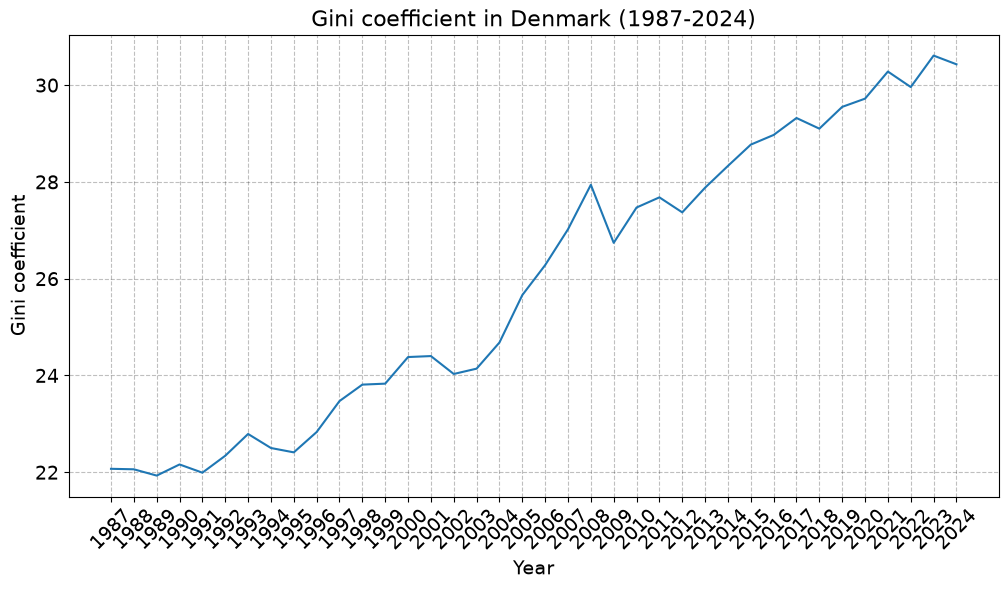

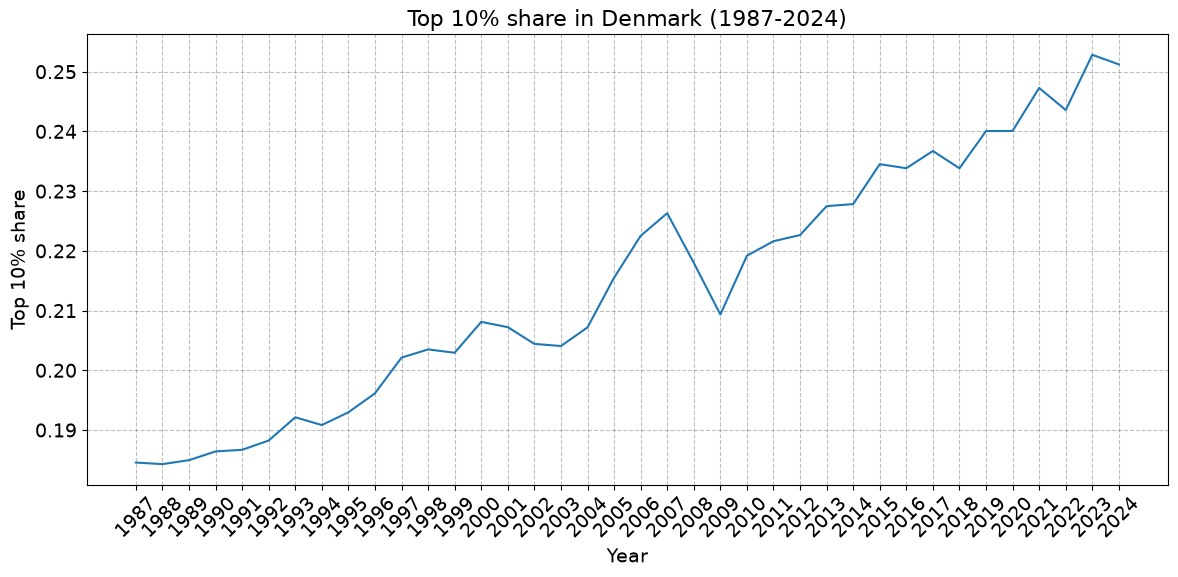

In [4]:
# Makes a Gini and top 10 pct. share plots for Denmark (municipalities = All Denmark) between 1987 and 2024.

fig, ax = plt.subplots(figsize=(12,6)) # Gini
fig, bx = plt.subplots(figsize=(12,6)) # Top 10 pct. share

# Gini coefficient plot
denmark.plot(y = 'gini', 
             ax = ax, 
             color = colors[0], 
             legend = False)

ax.set_xticks(denmark.index.unique()) # Year is set as the index.
ax.set_xticklabels(denmark.index.unique(), rotation=45)

ax.set_title('Gini coefficient in Denmark (1987-2024)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Gini coefficient', fontsize=14)

# Top 10 pct. share plot
denmark.plot(y = 'avg_income_top10_share', 
             ax = bx, 
             color = colors[0], 
                                                       legend = False)

bx.set_xticks(denmark.index.unique()) # Year is set as the index.
bx.set_xticklabels(denmark.index.unique(), rotation=45)

bx.set_title('Top 10% share in Denmark (1987-2024)', fontsize=16)
bx.set_xlabel('Year', fontsize=14)
bx.set_ylabel('Top 10% share', fontsize=14)

fig.tight_layout()

The Gini coefficient for Denmark rises over the whole period, indicating a gradual increase in income inequality from 1987 to 2024. At the same time, the share of total income going to the richest 10 percent follows the same pattern, rising alongside the Gini and showing temporary declines during economic downturns such as the dot-com bubble, the financial crisis and the COVID-19 pandemic. This suggests that higher inequality is strongly linked to the top income share, and to check this relationship we compute the correlation between the two series over time.

In [5]:
# Compute the correlation between Gini and top 10% share for Denmark between 1987 and 2024.

corr_gini_top10 = denmark['gini'].corr(denmark['avg_income_top10_share'])
print(f'The correlation between Gini and top 10% share in Denmark (1987-2024) is: {corr_gini_top10:.4f}')

The correlation between Gini and top 10% share in Denmark (1987-2024) is: 0.9816


Thus, the Gini coeficient and top 10% share for Denmark almost perfectly correlates between 1987 and 2024.

### Question 1.2: Prediction <a id='toc1_2_'></a>

We make the prediction by...

In [6]:
# Write the code here.

We find that ...

### Question 1.3: Municipalities <a id='toc1_3_'></a>

We look at different municipalities...

In [7]:
# Write the code here.

We find that ...

### Question 1.4: Extension <a id='toc1_4_'></a>

We look at the correlation between the Gini coefficient and the municipalities' equalization and grants, fertility and number of guilty persons per capita. Our initial hypothesis is that larger income inequality will lead to lower fertility, which makes the correlation negative. Conversely, we would expect that greater income inequality would lead to a higher crime rate, thus a positive correlation between the Gini coefficient and the number of guilty persons per capita. Finally, our initial hypothesis on the municipalities' equalization and grants is ambiguous. Richer municipalities could occur either because the general income level is high or because very few people have a very large income.

Thus, we start by exploring and downloading the relevant datasets from DST.

In [8]:
# Below are some lines of code to explore the datasets. 
# Theses are commented out in the final version of the notebook, 
# but they are used to get a better understanding of the data.

NGLK = DstApi('NGLK') # Municipalities equalization and grants dataset
FOD407 = DstApi('FOD407') # Fertility dataset
STRAFNA7 = DstApi('STRAFNA7') # Crime dataset
BEFOLK3 = DstApi('BEFOLK3') # Population dataset



#NGLK.tablesummary(language='en')
#NGLK.variable_levels('OMRÅDE',language='en') # Needs inner join with IFOR41 since we have few municipalities in IFOR41 and NGLK has fewer years.
#NGLK.variable_levels('BNØGLE',language='en') # Use UDL for Equalization and grants amount per capita
#NGLK.variable_levels('BRUTNETUDG',language='en') # Use NET for net expenditures
#NGLK.variable_levels('PRISENHED',language='en') # Use 08PRIS for Real prices


#FOD407.tablesummary(language='en')
#FOD407.variable_levels('ALDER',language='en') # Use TOT1 for Equalization and grants amount per capita


#STRAFNA7.tablesummary(language='en')
#STRAFNA7.variable_levels('OVERTRÆD',language='en') # Use 1 all crime code 

#BEFOLK3.tablesummary(language='en')
#BEFOLK3.variable_levels('KØN',language='en') # Use TOT for total population
#BEFOLK3.variable_levels('ALDER',language='en') # USE IALT for all ages



In [9]:
# Download datasets.
df_equal_muni = dataproject.load_NGLK(OMRÅDE = '*', BNØGLE = 'UDL', BRUTNETUDG = 'NET', PRISENHED = '08PRIS', varname = 'equalization_per_capita')
df_fert_muni = dataproject.load_FOD407(OMRÅDE = '*', ALDER = 'TOT1', varname = 'fertility')
df_crime_muni = dataproject.load_STRAFNA7(OMRÅDE = '*', OVERTRÆD = '1357', varname = 'crime_persons')
df_pop_muni = dataproject.load_BEFOLK3(OMRÅDE = '*', KØN = 'TOT', ALDER = 'IALT', varname = 'population')

# Keep only the Gini column from df_ineq, then merge by year and municipality.
df_corr = df_ineq.reset_index()[['year', 'municipality', 'gini']]

df_corr = (
    df_corr
    .merge(df_equal_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_fert_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_crime_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_pop_muni, on=['year', 'municipality'], how='inner', validate='1:1')
)

# Computes crime rate per capita and deletes crime_persons and population columns
df_corr['crime_rate'] = df_corr['crime_persons'] / df_corr['population']
del df_corr['crime_persons']
del df_corr['population']

df_corr = df_corr.set_index(['year']).sort_index().sort_values(by=['municipality'])

df_corr.head()

,municipality,gini,equalization_per_capita,fertility,crime_rate
year,,,,,
2008,Aabenraa,26.88,-17033.0,2075.0,0.000199
2009,Aabenraa,25.57,-19588.0,2177.6,0.000066
2010,Aabenraa,25.09,-24313.0,2037.3,0.000150
2011,Aabenraa,25.01,-25995.0,1962.2,0.000151
2012,Aabenraa,24.83,-28752.0,2003.8,0.000218


Now we plot the correlation between the Gini coeficient and the municipalities equalization and grants, fertility and numbers of guilty persons per capita.

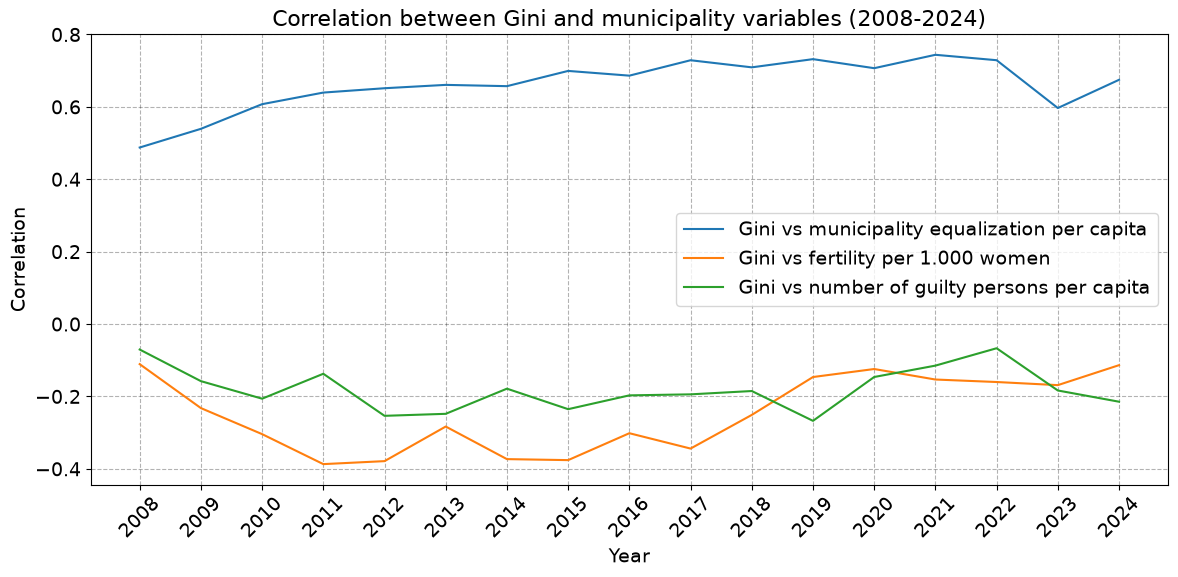

In [ ]:

# Correlations by year between Gini and both equalization and fertility
df_ineq_equal_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['equalization_per_capita']))
    .reset_index(name = 'corr_equalization')
)

df_ineq_fert_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['fertility']))
    .reset_index(name = 'corr_fertility')
)

df_ineq_crime_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['crime_rate']))
    .reset_index(name = 'corr_crime_rate')
)

df_corr_plot = df_ineq_equal_corr.merge(
    df_ineq_fert_corr,
    on = 'year',
    how = 'inner'
)

df_corr_plot = df_corr_plot.merge(
    df_ineq_crime_corr,
    on = 'year',
    how = 'inner'
)

# Plot both correlations
fig, ax = plt.subplots(figsize=(12, 6))

df_corr_plot.plot(
    x = 'year',
    y = 'corr_equalization',
    ax = ax,
    color = colors[0],
    legend = True,
    label = 'Gini vs municipality equalization per capita'
)

df_corr_plot.plot(
    x = 'year',
    y = 'corr_fertility',
    ax = ax,
    color = colors[1],
    legend = True,
    label = 'Gini vs fertility per 1.000 women'
)

df_corr_plot.plot(
    x = 'year',
    y = 'corr_crime_rate',
    ax = ax,
    color = colors[2],
    legend = True,
    label = 'Gini vs number of guilty persons per capita'
)

ax.set_xticks(df_corr_plot['year'].unique())
ax.set_xticklabels(df_corr_plot['year'].unique(), rotation=45)

ax.set_title('Correlation between Gini and municipality variables (2008-2024)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Correlation', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

The blue line (Gini vs equalization per capita) is strongly positive and rises from about 0.49 in 2008 to roughly 0.7, meaning higher inequality goes together with higher equalization grants. This resolves the ambiguous hypothesis toward the second explanation: municipalities appear unequal mainly because a few residents earn very much. The orange line (fertility) stays negative across the whole period, between about -0.11 and -0.39, which confirms the hypothesis that greater inequality is associated with lower fertility. The green line (guilty persons) is also negative throughout, roughly -0.07 to -0.26, which contradicts the initial hypothesis of a positive crime correlation, so more inequality does not track with more convictions per capita here.

## Question 2: Simulating the Income Distribution <a id='toc2_'></a>

### Question 2.1: The Model <a id='toc2_1_'></a>

We construct the model by...

In [11]:
# Write the code here.

We find that ...

### Question 2.2: Simulate the Income Distribution <a id='toc2_2_'></a>

We simulate the model by...

In [12]:
# Write the code here.

We find that ...

### Question 2.3: Compute the Gini Coefficient <a id='toc2_3_'></a>

We comepute the gini by...

In [13]:
# Write the code here.

We find that ...

### Question 2.4: What Drives Inequality? <a id='toc2_4_'></a>

We at inequality by...

In [14]:
# Write the code here.

We find that ...

### Question 2.5: Extension: More Risk <a id='toc2_5_'></a>

We extent the model by...

In [15]:
# Write the code here.

We find that ...